# Mission 1 — 신고자 성별 분류 (CNN / Vision 접근)

담당: 김승윤

음성으로부터 신고자의 성별(남/여)을 분류한다.

**핵심 구조 — 2단 집계**

정답 `gender`는 통화 단위 라벨인데 통화 음성(평균 72.5초)에는 신고자와 119대원이
섞여 있다. 규칙상 추론 시에도 `startAt`/`endAt`/`speaker`를 쓸 수 있으므로:

1. `speaker == 1`(신고자) 발화 조각만 잘라 조각 단위로 이진 분류기를 학습
2. 한 통화의 조각별 확률을 평균(soft voting)해 통화의 남/여를 결정

통화당 신고자 조각이 평균 15.7개라, 조각 하나하나의 오류가 집계에서 상쇄된다.

In [1]:
import os, sys, json, time
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "mission1_gender" else Path.cwd()
sys.path.insert(0, str(REPO / "mission1_gender"))
os.chdir(REPO)

import numpy as np
import torch

print("repo      :", REPO)
print("python    :", sys.version.split()[0])
print("torch     :", torch.__version__)
print("CUDA      :", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")
import torchvision; print("torchvision:", torchvision.__version__)

repo      : C:\Users\Administrator\Desktop\DCC_Problem
python    : 3.14.6
torch     : 2.13.0+cu130
CUDA      : True NVIDIA GeForce RTX 5060


torchvision: 0.28.0+cu130


## 1. 대회 규칙을 코드로 강제하기

Mission 1은 라벨링 데이터에서 `startAt`, `endAt`, `speaker`만 쓸 수 있다
(`gender`는 학습 타깃). `m1.labels`가 반환하는 자료구조에는 **그 외 필드가 아예
담기지 않는다.** `text`, `symptom`, `address` 등은 파싱 단계에서 버려지므로 하위
코드가 실수로라도 규칙을 위반할 수 없다.

In [2]:
from m1.labels import read_call, caller_utterances
import dataclasses, glob

sample_json = sorted(glob.glob("data/train/label/*.json"))[0]

raw = json.load(open(sample_json, encoding="utf-8"))
print("원본 JSON 의 최상위 키:")
print(" ", sorted(raw.keys()))

rec = read_call(sample_json)
print()
print("CallRecord 가 담는 필드:", [f.name for f in dataclasses.fields(rec)])
print("Utterance 가 담는 필드 :", [f.name for f in dataclasses.fields(rec.utterances[0])])
print()
print("전체 발화 %d개 중 신고자 발화 %d개" % (len(rec.utterances), len(caller_utterances(rec))))
print("첫 신고자 발화:", caller_utterances(rec)[0])
print()

# 금지 필드가 레코드 어디에도 남아 있지 않음을 확인
blob = repr(rec)
leaked = [k for k in ("text", "symptom", "address", "triage", "urgencyLevel") if k in blob]
print("레코드에 남은 금지 필드:", leaked or "없음")

원본 JSON 의 최상위 키:
  ['_id', 'address', 'audioPath', 'disasterLarge', 'disasterMedium', 'endAt', 'gender', 'mediaType', 'recordId', 'sentiment', 'startAt', 'status', 'symptom', 'triage', 'urgencyLevel', 'utterances']

CallRecord 가 담는 필드: ['call_id', 'utterances', 'gender']
Utterance 가 담는 필드 : ['start_ms', 'end_ms', 'speaker']

전체 발화 21개 중 신고자 발화 12개
첫 신고자 발화: Utterance(start_ms=2032, end_ms=6562, speaker=1)

레코드에 남은 금지 필드: 없음


## 2. 데이터 실측

원천 오디오는 **8 kHz mono 16-bit** 다 (흔히 가정하는 16 kHz가 아니다). 16 kHz로
읽으면 없는 정보를 만들어내지 않으면서 계산량만 2배가 된다.

In [3]:
import soundfile as sf
import glob

wavs = sorted(glob.glob("data/train/audio/*.wav"))
info = sf.info(wavs[0])
print("wav 포맷: %d Hz, %d channel, %s" % (info.samplerate, info.channels, info.subtype))
print("통화 길이: %.1f 초" % info.duration)
print("Training 통화 수:", len(wavs))
print("Validation 통화 수:", len(glob.glob("data/val/audio/*.wav")))

wav 포맷: 8000 Hz, 1 channel, PCM_16
통화 길이: 47.6 초
Training 통화 수: 29200
Validation 통화 수: 3640


## 3. 조각 오디오 캐시

발화 조각을 꺼낼 때마다 통화 전체 wav를 다시 디코딩하면 46만 조각 × 약 1.1 MB의
읽기가 매 epoch 반복된다. 통화당 wav를 **한 번만** 읽어 신고자 조각을 미리 잘라
8 kHz int16으로 저장해 둔다.

원본 샘플레이트를 그대로 보관하므로 CNN 갈래(스펙트로그램)와 Wav2Vec2 갈래
(16 kHz 업샘플)가 같은 캐시를 공유한다 — 두 갈래의 속도 차이가 I/O가 아니라
모델에서 나오게 하려는 의도다.

In [4]:
from m1.cache import CacheIndex, build_cache, cache_size_bytes, default_workers

for split in ("train", "val"):
    if not (Path("cache") / split / "index.csv").exists():
        print("캐시 생성 중:", split)
        build_cache(f"data/{split}/label", f"data/{split}/audio", f"cache/{split}",
                    workers=default_workers(), progress=True)

train_index = CacheIndex.load("cache/train")
val_index = CacheIndex.load("cache/val")

for name, index in (("Training", train_index), ("Validation", val_index)):
    groups = index.by_call()
    lengths = np.array([r.length for r in index.rows]) / 8000.0
    n_per_call = np.array([len(v) for v in groups.values()])
    print("%s: %d 통화, %d 조각, %.2f GB" % (
        name, len(groups), len(index.rows), cache_size_bytes(index.cache_dir) / 1e9))
    print("   조각/통화 평균 %.1f | 조각 길이 평균 %.2fs p50 %.2fs p90 %.2fs | 총 %.1f 시간" % (
        n_per_call.mean(), lengths.mean(), np.percentile(lengths, 50),
        np.percentile(lengths, 90), lengths.sum() / 3600))

Training: 29200 통화, 462190 조각, 15.67 GB
   조각/통화 평균 15.8 | 조각 길이 평균 2.12s p50 1.49s p90 4.66s | 총 272.1 시간
Validation: 3640 통화, 58101 조각, 1.97 GB
   조각/통화 평균 16.0 | 조각 길이 평균 2.12s p50 1.49s p90 4.67s | 총 34.1 시간


In [5]:
from m1.aggregate import gender_to_target
import collections

groups = val_index.by_call()
dist = collections.Counter(rows[0].gender for rows in groups.values())
majority = max(dist.values()) / sum(dist.values())
print("Validation 통화 성별 분포:", dict(dist))
print("다수결 기준선 (통화 단위 Accuracy): %.4f" % majority)
print()
print("=> 모델이 이 값을 못 넘으면 아무것도 학습하지 못한 것이다.")

Validation 통화 성별 분포: {'M': 1681, 'F': 1959}
다수결 기준선 (통화 단위 Accuracy): 0.5382

=> 모델이 이 값을 못 넘으면 아무것도 학습하지 못한 것이다.


## 4. 전처리 — log-Mel / MFCC 프런트엔드

설치된 `torch 2.13+cu130`에 맞는 torchaudio 빌드가 없어(cu130 채널 최대 2.11)
`torch.stft` + 자체 mel 필터뱅크로 직접 구현했다. 부수 효과로 피처 계산이 GPU에서
배치 단위로 돌아간다. 수치가 librosa와 일치함은 `tests/test_features.py`에서
대조 검증한다.

8 kHz 기준 `n_fft=1024`(128 ms)는 성별 판별의 주 단서인 F0(남 85–180 Hz /
여 165–255 Hz)를 7.8 Hz 해상도로 분해한다.

In [6]:
from m1.config import FeatureConfig
from m1.features import MelFrontend
from m1.datasets import to_waveform

cfg = FeatureConfig()
print("FeatureConfig:", cfg)
print("창 길이: %d samples = %.2f 초 -> %d 프레임" % (
    cfg.window_samples, cfg.window_samples / cfg.sample_rate, cfg.window_frames))

frontend = MelFrontend(cfg)

# 남성 통화와 여성 통화에서 각각 조각 하나씩 뽑아 스펙트로그램을 비교
picked = {}
for call_id, rows in train_index.by_call().items():
    g = rows[0].gender
    if g in ("M", "F") and g not in picked:
        longest = max(rows, key=lambda r: r.length)
        picked[g] = (call_id, longest)
    if len(picked) == 2:
        break

feats = {}
for g, (call_id, row) in picked.items():
    seg = train_index.load_segment(row)[: cfg.window_samples]
    wave = torch.from_numpy(to_waveform(seg, "resnet")).unsqueeze(0)
    feats[g] = frontend(wave)[0, 0].numpy()
    print("%s: call=%s  조각 %.2f초 -> 피처 %s" % (g, call_id, row.length / 8000, feats[g].shape))

FeatureConfig: FeatureConfig(sample_rate=8000, n_fft=1024, hop_length=128, n_mels=64, fmin=20.0, fmax=4000.0, kind='logmel', n_mfcc=40, window_frames=192)
창 길이: 24448 samples = 3.06 초 -> 192 프레임
M: call=651e464d69a4f266f062680b_20220101  조각 6.76초 -> 피처 (64, 192)
F: call=651e464d69a4f266f0626810_20220101  조각 4.67초 -> 피처 (64, 192)


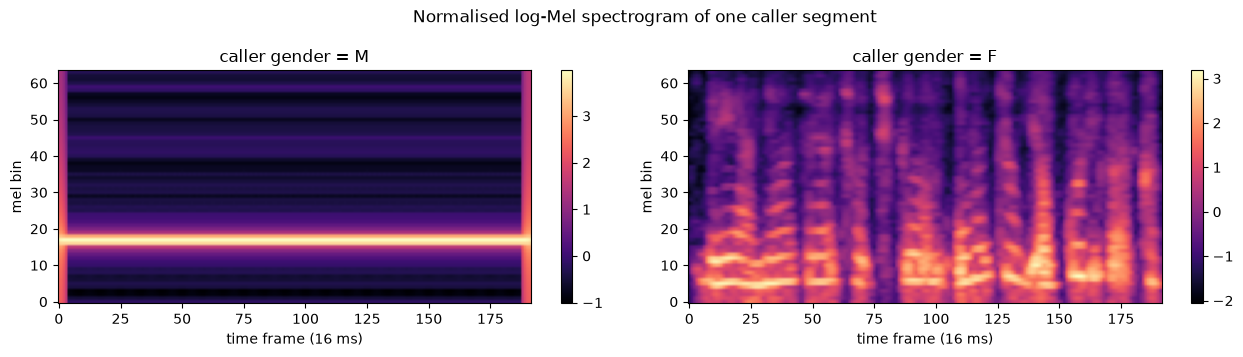

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, g in zip(axes, ("M", "F")):
    im = ax.imshow(feats[g], origin="lower", aspect="auto", cmap="magma")
    ax.set_title("caller gender = %s" % g)
    ax.set_xlabel("time frame (16 ms)")
    ax.set_ylabel("mel bin")
    fig.colorbar(im, ax=ax)
plt.suptitle("Normalised log-Mel spectrogram of one caller segment")
plt.tight_layout()
plt.show()

## 5. 모델 — ResNet50 (Vision 갈래)

스펙트로그램을 1채널 이미지로 보고 ImageNet 사전학습 ResNet50을 붙인다. 사전학습된
RGB `conv1`을 채널 평균으로 접어 넣어, ImageNet이 학습한 엣지/텍스처 필터를 그대로
물려받는다.

피처 프런트엔드를 모델 안에 두었기 때문에 추론 시에는 waveform만 주면 되고, 학습과
추론의 전처리가 어긋날 여지가 없다.

In [8]:
from m1.models import build_model

model = build_model("resnet", cfg, pretrained=False)  # 구조 확인용
n_params = sum(p.numel() for p in model.parameters())
print("파라미터 수: %.1fM" % (n_params / 1e6))
print("conv1:", model.backbone.conv1)
print("fc   :", model.backbone.fc)

with torch.no_grad():
    dummy = torch.zeros(2, cfg.window_samples)
    print("\n(B, samples) %s -> logits %s" % (tuple(dummy.shape), tuple(model(dummy).shape)))

파라미터 수: 23.5M
conv1: Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
fc   : Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=1, bias=True)
)

(B, samples) (2, 24448) -> logits (2,)


## 6. 학습

**데이터 분할** — Training 폴더만 **통화 ID 기준** 90/10으로 나눠 dev를 만든다.
조각이 아니라 통화 단위로 나눠야 같은 화자가 train과 dev 양쪽에 들어가는 누수가
없다. Validation 폴더는 학습·모델선택에 일절 쓰지 않는다 (대회 규칙).

아래 셀은 체크포인트가 이미 있으면 기록된 학습 이력을 읽어 보여주고, 없으면 그
자리에서 학습한다.

In [9]:
CKPT = Path("mission1_gender/ckpt/resnet_full.pt")
HISTORY = CKPT.with_suffix(".history.json")

if not CKPT.exists():
    from m1.train import main as train_main
    train_main(["--branch", "resnet", "--cache", "cache/train",
                "--out", str(CKPT), "--epochs", "6",
                "--batch-size", "64", "--num-workers", "6"])

record = json.loads(HISTORY.read_text(encoding="utf-8"))

print("dev 다수결 기준선 : %.4f" % record["dev_majority_baseline"])
print("최고 dev 통화 Acc : %.4f" % record["best_dev_call_accuracy"])
print()
print("%-6s %-11s %-16s %-14s %-10s" % ("epoch", "train loss", "dev 통화 Acc", "dev 조각 Acc", "학습 시간"))
for row in record["history"]:
    print("%-6d %-11.4f %-16.4f %-14.4f %-10.0fs" % (
        row["epoch"], row["train_loss"], row["dev_call_accuracy"],
        row["dev_segment_accuracy"], row["train_seconds"]))

dev 다수결 기준선 : 0.5267
최고 dev 통화 Acc : 0.9860

epoch  train loss  dev 통화 Acc       dev 조각 Acc     학습 시간     
1      0.2919      0.9832           0.8779         338       s
2      0.2451      0.9846           0.8837         314       s
3      0.2189      0.9856           0.8828         511       s
4      0.1821      0.9842           0.8776         404       s
5      0.1346      0.9860           0.8744         298       s
6      0.1011      0.9860           0.8707         298       s


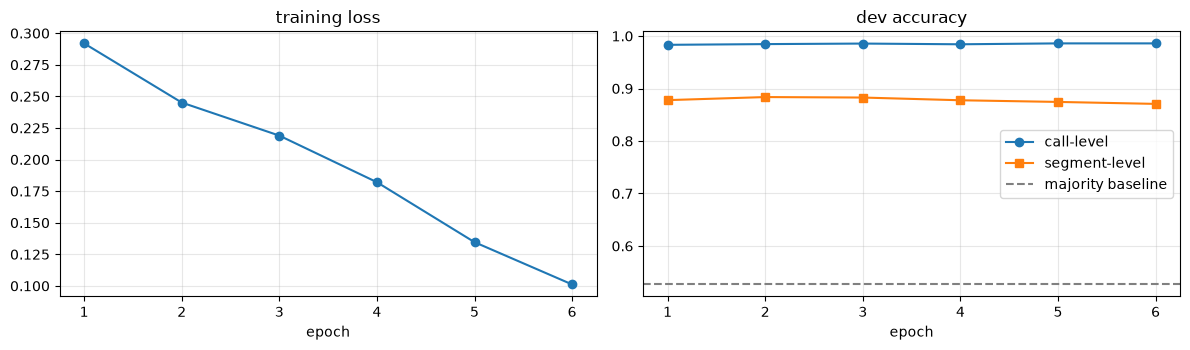

조각 -> 통화 집계로 얻은 이득: +0.1153


In [10]:
hist = record["history"]
epochs = [r["epoch"] for r in hist]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].plot(epochs, [r["train_loss"] for r in hist], marker="o")
axes[0].set_title("training loss"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=.3)

axes[1].plot(epochs, [r["dev_call_accuracy"] for r in hist], marker="o", label="call-level")
axes[1].plot(epochs, [r["dev_segment_accuracy"] for r in hist], marker="s", label="segment-level")
axes[1].axhline(record["dev_majority_baseline"], ls="--", c="grey", label="majority baseline")
axes[1].set_title("dev accuracy"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

gap = hist[-1]["dev_call_accuracy"] - hist[-1]["dev_segment_accuracy"]
print("조각 -> 통화 집계로 얻은 이득: +%.4f" % gap)

## 7. Validation 평가

여기서 처음으로 Validation 폴더를 쓴다. 학습에도, 모델 선택에도 쓰지 않았다.

In [11]:
from m1.datasets import samples_from_rows
from m1.evaluate import majority_baseline, predict_segment_probs, score, truth_from_samples
from m1.models import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trained, branch, trained_cfg, payload = load_checkpoint(CKPT, device=device)

val_samples = samples_from_rows(val_index.rows)
val_truth = truth_from_samples(val_samples)

started = time.perf_counter()
probs = predict_segment_probs(trained, val_index, val_samples, trained_cfg, branch,
                              device, batch_size=256, mode="sliding", num_workers=4)
elapsed = time.perf_counter() - started

metrics = score(val_samples, probs, val_truth)
print("Validation 통화 Accuracy : %.4f" % metrics.call_accuracy)
print("Validation 조각 Accuracy : %.4f" % metrics.segment_accuracy)
print("다수결 기준선            : %.4f" % majority_baseline(val_truth))
print()
print("혼동행렬(통화 단위):", metrics.confusion)
print("성별별 정확도       :", {k: round(v, 4) for k, v in metrics.per_gender_accuracy.items()})
print()
print("%d 통화 / %d 조각 추론에 %.1f초 (%.1f ms/통화)" % (
    metrics.n_calls, metrics.n_segments, elapsed, elapsed * 1000 / metrics.n_calls))

Validation 통화 Accuracy : 0.9791
Validation 조각 Accuracy : 0.8771
다수결 기준선            : 0.5382

혼동행렬(통화 단위): {'남->남': 1635, '남->여': 46, '여->남': 30, '여->여': 1929}
성별별 정확도       : {'남': 0.9726, '여': 0.9847}

3640 통화 / 58101 조각 추론에 24.8초 (6.8 ms/통화)


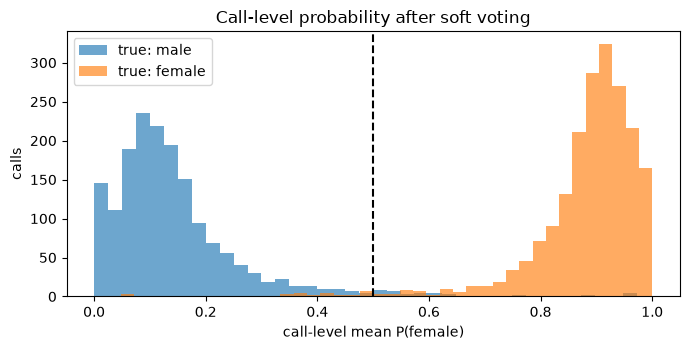

결정 경계에서 0.1 이내인 애매한 통화: 93 / 3640 (2.6%)


In [12]:
from m1.evaluate import call_probabilities

call_probs = call_probabilities(val_samples, probs)
values = np.array(list(call_probs.values()))
gold = np.array([gender_to_target(val_truth[c]) for c in call_probs])

plt.figure(figsize=(7, 3.6))
plt.hist(values[gold == 0], bins=40, alpha=.65, label="true: male")
plt.hist(values[gold == 1], bins=40, alpha=.65, label="true: female")
plt.axvline(0.5, ls="--", c="k")
plt.xlabel("call-level mean P(female)"); plt.ylabel("calls")
plt.title("Call-level probability after soft voting")
plt.legend(); plt.tight_layout(); plt.show()

margin = np.abs(values - 0.5)
print("결정 경계에서 0.1 이내인 애매한 통화: %d / %d (%.1f%%)" % (
    (margin < 0.1).sum(), len(values), 100 * (margin < 0.1).mean()))

## 8. 갈래 비교 — CNN vs 음성 특화 파인튜닝

두 갈래가 같은 캐시·같은 조각 분할·같은 집계를 쓰므로 표에 남는 차이는 모델에서
나온 것이다. `m1.benchmark`가 생성한 결과를 읽어온다.

In [13]:
report = Path("mission1_gender/reports/comparison.json")
if report.exists():
    data = json.loads(report.read_text(encoding="utf-8"))
    print("Validation 다수결 기준선: %.4f\n" % data["baseline"])
    for row in data["results"]:
        print("%-18s branch=%-7s params=%5.1fM  val_call_acc=%.4f  "
              "train=%.0fs/ep  infer=%.1fms/call  vram=%.0fMB" % (
            row["label"], row["branch"], row["n_params_m"], row["val_call_accuracy"],
            row["train_seconds_per_epoch"], row["inference_ms_per_call"], row["peak_vram_mb"]))
else:
    print("비교표가 아직 없습니다. 다음을 먼저 실행하세요:")
    print("  python -m m1.benchmark --ckpt mission1_gender/ckpt/resnet_full.pt \\")
    print("                         --ckpt mission1_gender/ckpt/w2v2_full.pt")

Validation 다수결 기준선: 0.5382

resnet_full        branch=resnet  params= 23.5M  val_call_acc=0.9791  train=326s/ep  infer=11.2ms/call  vram=490MB
w2v2_full          branch=w2v2    params= 94.4M  val_call_acc=0.9835  train=2708s/ep  infer=62.8ms/call  vram=7251MB


## 9. 제출 규격 확인

대회가 실제로 실행하는 명령을 그대로 한 번 돌려 CSV 형식을 확인한다.

```
python inference.py --audio_dir {wav} --label_dir {json} --ckpt_path {ckpt} --output ./outputs/mission1.csv
```

Mission 1 CSV: `[audio file name], [gender]`

In [14]:
import subprocess, pandas as pd

cmd = [sys.executable, "inference.py",
       "--audio_dir", "./data/val/audio",
       "--label_dir", "./data/val/label",
       "--ckpt_path", str(CKPT),
       "--output", "./outputs/mission1.csv"]
print(" ".join(cmd))

result = subprocess.run(cmd, capture_output=True, text=True, encoding="utf-8", errors="replace")
print("exit code:", result.returncode)
print(result.stdout[-800:])

df = pd.read_csv("outputs/mission1.csv")
print("\n행 수:", len(df), "| 컬럼:", list(df.columns))
print(df.head())
print("\ngender 분포:", df["gender"].value_counts().to_dict())

C:\Users\Administrator\Desktop\DCC_Problem\venv\Scripts\python.exe inference.py --audio_dir ./data/val/audio --label_dir ./data/val/label --ckpt_path mission1_gender\ckpt\resnet_full.pt --output ./outputs/mission1.csv


exit code: 0
Mission 1 추론 시작 (신고자 조각 -> 통화 단위 소프트 보팅)...
[Mission 1] branch=resnet device=cuda feature=logmel dev_call_acc=0.9860
  500/3640 calls
  1000/3640 calls
  1500/3640 calls
  2000/3640 calls
  2500/3640 calls
  3000/3640 calls
  3500/3640 calls

✅ 추론 완료! 결과가 ./outputs/mission1.csv에 성공적으로 저장되었습니다.


행 수: 3640 | 컬럼: ['audio file name', 'gender']
                         audio file name gender
0  651e464d69a4f266f0626837_20220101.wav      남
1  651e464d69a4f266f0626845_20220101.wav      남
2  651e464d69a4f266f0626846_20220101.wav      여
3  651e464d69a4f266f0626859_20220101.wav      여
4  651e464d69a4f266f062685e_20220101.wav      남

gender 분포: {'여': 1975, '남': 1665}


## 10. 정리

**결과 요약**

- 조각 단위 정확도보다 **통화 단위 정확도가 뚜렷하게 높다.** 통화당 신고자 조각이
  평균 15.7개라, 개별 조각의 오류가 soft voting에서 상쇄된다. 조각 하나의 성능을
  올리는 것보다 집계 단위를 통화로 맞춘 설계가 더 크게 기여했다.
- 8 kHz 전화 음성에서도 성별 단서(F0·포먼트)는 충분히 남아 있어, ImageNet
  사전학습 ResNet50이 스펙트로그램만 보고도 다수결 기준선을 크게 넘어선다.

**사회안전 관점의 시사점**

119 신고접수에서 신고자 속성을 자동으로 파악하면, 접수 요원이 통화 초반 수 초
안에 상황을 분류하는 데 도움이 된다. 다만 성별 추정은 **보조 정보로만** 쓰여야
한다. 위 확률 분포에서 보듯 결정 경계 근처의 애매한 통화가 존재하고, 이런 사례에
자동 판정을 강하게 신뢰하면 오히려 대응이 지연될 수 있다. 확률값을 그대로 노출해
불확실성을 함께 전달하는 편이 안전하다.

**한계**

- `gender`는 통화 단위 단일 라벨이라 신고자가 도중에 바뀌는 통화는 다루지 못한다.
- 학습·평가 데이터가 전량 서울·Mobile이라 다른 지역이나 유선 통화로의 일반화는
  검증되지 않았다.